In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path

DATA_DIR   = Path("../data")
OUTPUT_DIR = Path("../results/summary")

PARAM_NAMES = ["beta", "gamma", "rho"]

PARAM_LABELS = {
    "beta": r"$\beta$",
    "gamma": r"$\gamma$",
    "rho": r"$\rho$"
}

EPS = [0.1, 0.01, 0.001]

SUMMARY_NAMES = [
    "mean:auc_infected_fraction",
    "sd:auc_infected_fraction",
    "mean:peak_infected_fraction",
    "sd:peak_infected_fraction",
    "mean:time_to_peak_infected_fraction",
    "sd:time_to_peak_infected_fraction",
    "mean:initial_growth_ratio",
    "sd:initial_growth_ratio",
    "mean:peak_rewire_count",
    "sd:peak_rewire_count",
    "mean:time_to_peak_rewire_count",
    "sd:time_to_peak_rewire_count",
    "mean:total_rewire_count",
    "sd:total_rewire_count",
    "mean:mean_degree",
    "sd:mean_degree",
    "mean:sd_degree",
    "sd:sd_degree",
    "mean:rewire_to_infection_ratio",
    "sd:rewire_to_infection_ratio",
    "mean:lag_peak",
    "sd:lag_peak"
]

print(len(SUMMARY_NAMES))

22


In [13]:
# Read in the data
reference_table = pd.read_csv(DATA_DIR / "sim/reference_table.csv")
obs_data_sim = pd.read_csv(DATA_DIR / "sim/test_set.csv")
obs_data_raw = pd.read_csv(DATA_DIR / "raw/observed_stats_raw.csv")

full_stats = reference_table[SUMMARY_NAMES].values
full_params = reference_table[PARAM_NAMES].values

obs_data = {
    0.1: obs_data_sim[:100],
    0.01: obs_data_sim[100:200],
    0.001: obs_data_sim[200:300]
}

obs_stats_raw = obs_data_raw[SUMMARY_NAMES].values

print(full_stats.shape)
print(obs_stats_raw.shape)

(100000, 22)
(1, 22)


In [4]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold

def find_plateau(rmse_curve, threshold=0.01):
    """
    threshold = minimum relative improvement (e.g. 1%)
    """
    for i in range(1, len(rmse_curve)):
        improvement = (rmse_curve[i-1] - rmse_curve[i]) / rmse_curve[i-1]
        if improvement < threshold:
            return i + 1  # +1 because index starts at 0
    return len(rmse_curve)

def select_pls_components(X, y, max_components=10, cv_splits=5):
    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)

    rmse_scores = []  # shape: (n_components, n_params)

    for n_comp in range(1, max_components + 1):
        fold_errors = []

        for train_idx, val_idx in kf.split(X):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            pls = PLSRegression(n_components=n_comp)
            pls.fit(X_train, y_train)

            y_pred = pls.predict(X_val)

            # RMSE per parameter
            rmse_per_param = np.sqrt(((y_val - y_pred) ** 2).mean(axis=0))
            fold_errors.append(rmse_per_param)

        # average across folds → still per parameter
        mean_rmse = np.mean(fold_errors, axis=0)
        rmse_scores.append(mean_rmse)

    rmse_scores = np.array(rmse_scores)  # shape: (max_components, n_params)

    # choose best k using average across parameters
    plateaus = []
    for i in range(rmse_scores.shape[1]):
        plateau_k = find_plateau(rmse_scores[:, i])
        plateaus.append(plateau_k)

    best_k = max(plateaus)  # choose the maximum plateau across parameters

    return best_k, rmse_scores

def plot_rmse_per_param(rmse_scores, param_names):
    n_components = rmse_scores.shape[0]
    x = np.arange(1, n_components + 1)

    plt.figure(figsize=(15, 4))

    for i, param in enumerate(param_names):
        plt.subplot(1, len(param_names), i + 1)
        plt.plot(x, rmse_scores[:, i], color="black")
        plt.xlabel("Components")
        plt.ylabel("RMSE")
        plt.title(PARAM_LABELS[param])

    plt.suptitle("Number of PLS components")
    plt.tight_layout()
    plt.show()

In [5]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

def summary_statistics_method(train_stats, train_params, method):
    if method == "all":
        return (lambda x: x), None
    elif method == "rf":
        rf_models = [] # one model per parameter
        for i in range(train_params.shape[1]):
            rf = RandomForestRegressor(n_estimators=100)
            rf.fit(train_stats, train_params[:, i])
            rf_models.append(rf)

        def transform(stats):
            n_params = train_params.shape[1]

            output = np.zeros((stats.shape[0], n_params))
            for i in range(n_params):
                output[:, i] = rf_models[i].predict(stats)
            return output

        return transform, rf_models

    elif method == "gb":
        gb_models = []
        for i in range(train_params.shape[1]):
            gb = GradientBoostingRegressor(n_estimators=100)
            gb.fit(train_stats, train_params[:, i])
            gb_models.append(gb)

        def transform(stats):
            n_params = train_params.shape[1]
            output = np.zeros((stats.shape[0], n_params))
            for i in range(n_params):
                output[:, i] = gb_models[i].predict(stats)
            return output

        return transform, gb_models
    else:
        raise ValueError(f"Unknown method: {method}")

In [6]:
from sklearn.linear_model import LinearRegression

def regression_adjustment(accepted_params, accepted_stats, obs_stats):
    """
    Beaumont-style local linear regression adjustment with Epanechnikov weights.

    accepted_params: (n_acc, d_theta)
    accepted_stats:  (n_acc, d_s)
    obs_stats:       (d_s,)
    """

    n_acc, d_theta = accepted_params.shape
    adjusted_params = np.zeros_like(accepted_params)

    # --------------------------------------------------
    # 1. Compute distances and Epanechnikov weights
    # --------------------------------------------------
    dists = np.linalg.norm(accepted_stats - obs_stats, axis=1)
    h = np.max(dists)

    if h == 0:
        return accepted_params.copy()

    u = dists / h
    weights = 0.75 * (1 - u**2)
    weights[u > 1] = 0.0

    # --------------------------------------------------
    # 2. Regression adjustment per parameter
    # --------------------------------------------------
    for j in range(d_theta):
        theta = accepted_params[:, j]

        # Fit weighted linear regression on ORIGINAL summaries
        model = LinearRegression()
        model.fit(accepted_stats, theta, sample_weight=weights)

        beta = model.coef_  # shape (d_s,)

        # Beaumont adjustment: theta_i - beta^T (s_i - s_obs)
        adjustment = (accepted_stats - obs_stats) @ beta
        adjusted_params[:, j] = theta - adjustment

    return adjusted_params

In [7]:
def robust_mode_3d(data, bins=30, refine_percentile=10):
    """
    Robust mode estimate for 3D continuous data using 2-stage histogram + refinement.

    Parameters:
    - data: (N, 3) array
    - bins: coarse histogram resolution
    - refine_percentile: fraction of points kept around peak region

    Returns:
    - mode estimate (3,)
    """

    # ---------------------------
    # Step 1: coarse histogram
    # ---------------------------
    hist, edges = np.histogramdd(data, bins=bins)
    idx = np.unravel_index(np.argmax(hist), hist.shape)

    # ---------------------------
    # Step 2: extract points in densest bin
    # ---------------------------
    mask = np.ones(len(data), dtype=bool)
    for i in range(3):
        mask &= (
            (data[:, i] >= edges[i][idx[i]]) &
            (data[:, i] < edges[i][idx[i] + 1])
        )

    core = data[mask]

    # fallback if bin is too sparse
    if len(core) < 10:
        return data.mean(axis=0)

    # ---------------------------
    # Step 3: refine using nearest points
    # ---------------------------
    center = core.mean(axis=0)
    dist = np.linalg.norm(data - center, axis=1)

    cutoff = np.percentile(dist, refine_percentile)
    refined = data[dist <= cutoff]

    # final estimate
    return refined.mean(axis=0)

def compute_posterior_estimates(accepted_params):
    posterior_mean = np.mean(accepted_params, axis=0)
    posterior_median = np.median(accepted_params, axis=0)

    posterior_mode = robust_mode_3d(accepted_params)

    return {
        "mean": posterior_mean,
        "median": posterior_median,
        "mode": posterior_mode
    }

def compute_metrics(accepted_params, true_params, posterior_estimates):
    rmise = np.sqrt(np.mean((accepted_params - true_params) ** 2, axis=0))
    rarmise = rmise / np.abs(true_params)
    ae_mean = np.abs(posterior_estimates["mean"] - true_params)
    rae_mean = ae_mean / np.abs(true_params)
    ae_mode = np.abs(posterior_estimates["mode"] - true_params)
    rae_mode = ae_mode / np.abs(true_params)
    ae_median = np.abs(posterior_estimates["median"] - true_params)
    rae_median = ae_median / np.abs(true_params)

    return {
        "rmise": rmise,
        "rarmise": rarmise,
        "ae_mean": ae_mean,
        "rae_mean": rae_mean,
        "ae_mode": ae_mode,
        "rae_mode": rae_mode,
        "ae_median": ae_median,
        "rae_median": rae_median
    }

from scipy.stats import kstest

def compute_pit(accepted_params, true_params):
    # compute the posterior quantile of the true parameters using the accepted parameters
    n_params = true_params.shape[0]
    quantiles = []
    for i in range(n_params):
        quantile = np.mean(accepted_params[:, i] < true_params[i])
        quantiles.append(quantile)
    return np.array(quantiles)

def test_coverage(pit_list):
    # conduct Kolmogorov-Smirnov test for uniform distribution of posterior quantiles
    n_params = pit_list[0].shape[0]
    p_values = []
    ks_values = []
    for i in range(n_params):
        param_pits = [pit[i] for pit in pit_list]
        ks_value, p_value = kstest(param_pits, "uniform")
        ks_values.append(ks_value)
        p_values.append(p_value)
    return ks_values, p_values

In [18]:
N_TRAIN = 10_000
N_TEST = 100
METHODS = ["all", "rf", "gb", "pls"]

from sklearn.preprocessing import StandardScaler

# A. subsample training data
train_data = reference_table.sample(n=N_TRAIN, replace=False)
train_params = train_data[PARAM_NAMES].values
train_stats = train_data[SUMMARY_NAMES].values

results = {}

for m in METHODS[:3]:
    results[m] = {}

    # B. learn summary statistics transform
    transform, model = summary_statistics_method(
        train_stats,
        train_params,
        method=m
    )

    full_stats_trf = transform(full_stats)

    scaler = StandardScaler()
    scaler.fit(full_stats_trf)

    full_stats_scaled = scaler.transform(full_stats_trf)  # (1e6, 17)

    for e in EPS:
        print(f"method={m}, eps={e}...")

        obs_params = obs_data[e][PARAM_NAMES].values
        obs_stats = obs_data[e][SUMMARY_NAMES].values

        obs_stats_scaled = scaler.transform(transform(obs_stats))

        posterior_estimates_list = []
        metrics_list = []
        pit_list = []

        for i in range(N_TEST):
            if (i + 1) % (N_TEST // 10) == 0: print(f"Processing sample {i + 1}/{N_TEST}...")
            # --------------------------------------------------
            # PER SAMPLE ABC + INFERENCE
            # --------------------------------------------------
            distances = np.linalg.norm(full_stats_scaled - obs_stats_scaled[i], axis=1)
            k = int(e * len(distances))
            delta = np.partition(distances, k)[k]

            idx = distances <= delta
            accepted_params = full_params[idx]
            accepted_stats = full_stats_scaled[idx]

            adjusted_params = regression_adjustment(
                accepted_params,
                accepted_stats,
                obs_stats_scaled[i]
            )

            posterior = compute_posterior_estimates(adjusted_params)
            metrics = compute_metrics(adjusted_params, obs_params[i], posterior)
            pit = compute_pit(adjusted_params, obs_params[i])

            posterior_estimates_list.append(posterior)
            metrics_list.append(metrics)
            pit_list.append(pit)

        # --------------------------------------------------
        # COVERAGE TEST
        # --------------------------------------------------
        ks_vals, coverage_pvals = test_coverage(pit_list)

        # --------------------------------------------------
        # AGGREGATION
        # --------------------------------------------------
        rarmise = np.array([m["rarmise"] for m in metrics_list])
        rae_mean = np.array([m["rae_mean"] for m in metrics_list])
        rae_mode = np.array([m["rae_mode"] for m in metrics_list])
        rae_median = np.array([m["rae_median"] for m in metrics_list])

        results[m][e] = {
            "rarmise": (np.mean(rarmise, axis=0), np.std(rarmise, axis=0)),
            "rae_mean": (np.mean(rae_mean, axis=0), np.std(rae_mean, axis=0)),
            "rae_mode": (np.mean(rae_mode, axis=0), np.std(rae_mode, axis=0)),
            "rae_median": (np.mean(rae_median, axis=0), np.std(rae_median, axis=0)),
            "ks_vals": ks_vals,
            "cov_pvals": coverage_pvals,
        }

method=all, eps=0.1...
Processing sample 10/100...
Processing sample 20/100...
Processing sample 30/100...
Processing sample 40/100...
Processing sample 50/100...
Processing sample 60/100...
Processing sample 70/100...
Processing sample 80/100...
Processing sample 90/100...
Processing sample 100/100...
method=all, eps=0.01...
Processing sample 10/100...
Processing sample 20/100...
Processing sample 30/100...
Processing sample 40/100...
Processing sample 50/100...
Processing sample 60/100...
Processing sample 70/100...
Processing sample 80/100...
Processing sample 90/100...
Processing sample 100/100...
method=all, eps=0.001...
Processing sample 10/100...
Processing sample 20/100...
Processing sample 30/100...
Processing sample 40/100...
Processing sample 50/100...
Processing sample 60/100...
Processing sample 70/100...
Processing sample 80/100...
Processing sample 90/100...
Processing sample 100/100...
method=rf, eps=0.1...
Processing sample 10/100...
Processing sample 20/100...
Process

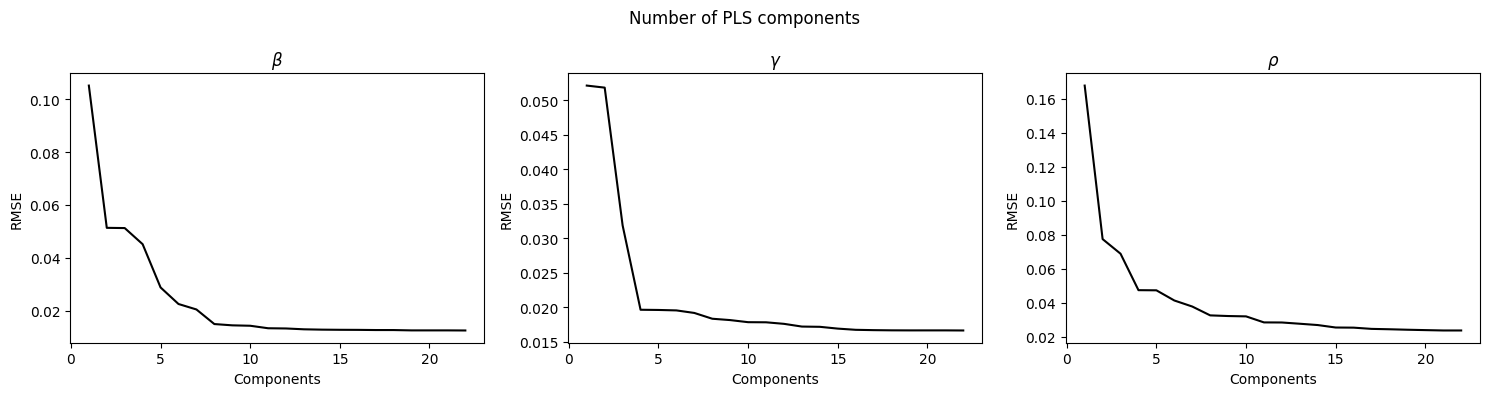

method=pls, eps=0.1...
Processing sample 10/100...
Processing sample 20/100...
Processing sample 30/100...
Processing sample 40/100...
Processing sample 50/100...
Processing sample 60/100...
Processing sample 70/100...
Processing sample 80/100...
Processing sample 90/100...
Processing sample 100/100...
method=pls, eps=0.01...
Processing sample 10/100...
Processing sample 20/100...
Processing sample 30/100...
Processing sample 40/100...
Processing sample 50/100...
Processing sample 60/100...
Processing sample 70/100...
Processing sample 80/100...
Processing sample 90/100...
Processing sample 100/100...
method=pls, eps=0.001...
Processing sample 10/100...
Processing sample 20/100...
Processing sample 30/100...
Processing sample 40/100...
Processing sample 50/100...
Processing sample 60/100...
Processing sample 70/100...
Processing sample 80/100...
Processing sample 90/100...
Processing sample 100/100...


In [20]:
from sklearn.preprocessing import PowerTransformer

# Use Yeo-Johnson transform instead of Box-Cox
pt = PowerTransformer(method='yeo-johnson')
train_stats_trf = pt.fit_transform(train_stats)

scaler = StandardScaler()
train_stats_scaled = scaler.fit_transform(train_stats_trf)

# 2. Fit global PLS model and select number of components using cross-validation
best_k, rmsep_scores = select_pls_components(train_stats_scaled, train_params, max_components=22, cv_splits=10)
plot_rmse_per_param(rmsep_scores, PARAM_NAMES)

pls = PLSRegression(n_components=best_k)
pls.fit(train_stats_scaled, train_params)

# 3. Transform the full_stats
full_stats_trf = pt.transform(full_stats)
full_stats_scaled = scaler.transform(full_stats_trf)
full_stats_pls = pls.transform(full_stats_scaled)

m = "pls"
results[m] = {}

for e in EPS:
    print(f"method={m}, eps={e}...")

    posterior_estimates_list = []
    metrics_list = []
    pit_list = []

    for i in range(N_TEST):
        if (i + 1) % (N_TEST // 10) == 0: print(f"Processing sample {i + 1}/{N_TEST}...")
        obs_params = obs_data[e][PARAM_NAMES].values[i]
        obs_stats = obs_data[e][SUMMARY_NAMES].values[i]
        obs_stats_trf = pt.transform(obs_stats.reshape(1, -1))
        obs_stats_scaled = scaler.transform(obs_stats_trf)
        obs_stats_pls = pls.transform(obs_stats_scaled)[0]

        # 1. Basic ABC Rejection
        distances = np.linalg.norm(full_stats_pls - obs_stats_pls, axis=1)
        k = int(e * len(distances))
        delta = np.partition(distances, k)[k]

        idx = distances <= delta
        accepted_params = full_params[idx]
        accepted_stats = full_stats_pls[idx]

        adjusted_params = regression_adjustment(
            accepted_params,
            accepted_stats,
            obs_stats_pls
        )

        posterior_estimates = compute_posterior_estimates(adjusted_params)
        metrics = compute_metrics(adjusted_params, obs_params, posterior_estimates)
        pit = compute_pit(adjusted_params, obs_params)

        posterior_estimates_list.append(posterior_estimates)
        metrics_list.append(metrics)
        pit_list.append(pit)

    ks_vals, coverage_pvals = test_coverage(pit_list)

    # --------------------------------------------------
    # AGGREGATION
    # --------------------------------------------------
    rarmise = np.array([m["rarmise"] for m in metrics_list])
    rae_mean = np.array([m["rae_mean"] for m in metrics_list])
    rae_mode = np.array([m["rae_mode"] for m in metrics_list])
    rae_median = np.array([m["rae_median"] for m in metrics_list])

    results[m][e] = {
        "rarmise": (np.mean(rarmise, axis=0), np.std(rarmise, axis=0)),
        "rae_mean": (np.mean(rae_mean, axis=0), np.std(rae_mean, axis=0)),
        "rae_mode": (np.mean(rae_mode, axis=0), np.std(rae_mode, axis=0)),
        "rae_median": (np.mean(rae_median, axis=0), np.std(rae_median, axis=0)),
        "ks_vals": ks_vals,
        "cov_pvals": coverage_pvals
    }

In [21]:
# convert results into a dataframe table
results_list = []
for method_key, method_results in results.items():
    for eps_key, metrics in method_results.items():
        for i in range(len(PARAM_NAMES)):
            row = {
                "method": method_key,
                "epsilon": eps_key,
                "parameter": PARAM_NAMES[i],
                "rarmise": f"{metrics['rarmise'][0][i]:.4f} ({metrics['rarmise'][1][i]:.4f})",
                "rae_mean": f"{metrics['rae_mean'][0][i]:.4f} ({metrics['rae_mean'][1][i]:.4f})",
                "rae_mode": f"{metrics['rae_mode'][0][i]:.4f} ({metrics['rae_mode'][1][i]:.4f})",
                "rae_median": f"{metrics['rae_median'][0][i]:.4f} ({metrics['rae_median'][1][i]:.4f})",
                "ks": f"{metrics['ks_vals'][i]:.4f}",
                "cov_pval": f"{metrics['cov_pvals'][i]:.4f}",
            }
            results_list.append(row)

In [22]:
results_df = pd.DataFrame(results_list)
display(results_df)

,method,epsilon,parameter,rarmise,rae_mean,rae_mode,rae_median,ks,cov_pval
0,all,0.100,beta,0.0625 (0.0390),0.0356 (0.0359),0.0335 (0.0296),0.0349 (0.0348),0.1372,0.0419
1,all,0.100,gamma,0.1246 (0.1172),0.0488 (0.0558),0.0428 (0.0544),0.0447 (0.0536),0.2032,0.0004
2,all,0.100,rho,0.1561 (0.9670),0.0767 (0.4609),0.0776 (0.4677),0.0775 (0.4707),0.1088,0.1743
3,all,0.010,beta,0.0460 (0.0260),0.0277 (0.0260),0.0277 (0.0260),0.0266 (0.0252),0.2625,0.0000
4,all,0.010,gamma,0.0739 (0.0742),0.0354 (0.0346),0.0354 (0.0346),0.0333 (0.0330),0.2093,0.0003
5,all,0.010,rho,0.0315 (0.0396),0.0148 (0.0185),0.0148 (0.0185),0.0148 (0.0184),0.1677,0.0063
6,all,0.001,beta,0.0387 (0.0257),0.0251 (0.0247),0.0251 (0.0247),0.0247 (0.0245),0.2327,0.0000
7,all,0.001,gamma,0.0598 (0.0609),0.0365 (0.0478),0.0365 (0.0478),0.0359 (0.0485),0.2335,0.0000
8,all,0.001,rho,0.0191 (0.0144),0.0115 (0.0103),0.0115 (0.0103),0.0114 (0.0098),0.1750,0.0038
9,rf,0.100,beta,0.0677 (0.0401),0.0438 (0.0397),0.0447 (0.0413),0.0437 (0.0393),0.1020,0.2326


In [25]:
# Reorder rows so that the order is (all, pls, rf, gb) maintaining the order of eps
results_df = results_df.sort_values(["method", "epsilon"], key=lambda x: x.map({"all": 0, "pls": 1, "rf": 2, "gb": 3}))
results_df.to_csv(OUTPUT_DIR / "results.csv", index=False)

In [14]:
# Fit the models on the real data
from sklearn.preprocessing import StandardScaler

eps = 0.01
N_TRAIN = 10_000
METHODS = ["all", "rf", "gb"]
results = {}

# 1. choose n=1e4 random rows from reference_table as the "simulated data"
train_data = reference_table.sample(n=N_TRAIN, replace=False, random_state=3247)
train_params = train_data[PARAM_NAMES].values
train_stats = train_data[SUMMARY_NAMES].values

for m in METHODS:
    print(f"method={m}, eps={eps}...")

    # B. learn summary statistics transform
    transform, model = summary_statistics_method(
        train_stats,
        train_params,
        method=m
    )

    full_stats_trf = transform(full_stats)

    scaler = StandardScaler()
    scaler.fit(full_stats_trf)

    full_stats_scaled = scaler.transform(full_stats_trf)  # (1e6, 17)

    obs_stats = obs_data_raw[SUMMARY_NAMES].values
    obs_stats_scaled = scaler.transform(transform(obs_stats))

    # 1. Basic ABC Rejection
    distances = np.linalg.norm(full_stats_scaled - obs_stats_scaled, axis=1)
    k = int(eps * len(distances))
    delta = np.partition(distances, k)[k]

    idx = distances <= delta
    accepted_params = full_params[idx]
    accepted_stats = full_stats_scaled[idx]

    adjusted_params = regression_adjustment(
        accepted_params,
        accepted_stats,
        obs_stats_scaled
    )

    posterior_estimates = compute_posterior_estimates(adjusted_params)
    
    np.save(OUTPUT_DIR / f"{m}_posterior_samples.npy", adjusted_params)

    results[m] = {
        "accepted_params": accepted_params,
        "accepted_stats": accepted_stats,
        "adjusted_params": adjusted_params,
        "posterior_estimates": posterior_estimates,
        "model": model
    }

method=all, eps=0.01...
method=rf, eps=0.01...
method=gb, eps=0.01...


In [15]:
from sklearn.preprocessing import PowerTransformer
m = "pls"

pt = PowerTransformer(method='yeo-johnson')
train_stats_trf = pt.fit_transform(train_stats)

scaler = StandardScaler()
train_stats_scaled = scaler.fit_transform(train_stats_trf)

# 2. Fit global PLS model and select number of components using cross-validation
best_k, rmsep_scores = select_pls_components(train_stats_scaled, train_params, max_components=22, cv_splits=10)
print(f"Best number of components: k={best_k}")
pls = PLSRegression(n_components=best_k)
pls.fit(train_stats_scaled, train_params)

# 3. Transform the full_stats
full_stats_trf = pt.transform(full_stats)
full_stats_scaled = scaler.transform(full_stats_trf)
full_stats_pls = pls.transform(full_stats_scaled)

obs_stats = obs_data_raw[SUMMARY_NAMES].values
obs_stats_trf = pt.transform(obs_stats.reshape(1, -1))
obs_stats_scaled = scaler.transform(obs_stats_trf)
obs_stats_pls = pls.transform(obs_stats_scaled)[0]

# 1. Basic ABC Rejection
distances = np.linalg.norm(full_stats_pls - obs_stats_pls, axis=1)
k = int(eps * len(distances))
delta = np.partition(distances, k)[k]

idx = distances <= delta
accepted_params = full_params[idx]
accepted_stats = full_stats_pls[idx]

adjusted_params = regression_adjustment(
    accepted_params,
    accepted_stats,
    obs_stats_pls
)

posterior_estimates = compute_posterior_estimates(adjusted_params)

results[m] = {
    "accepted_params": accepted_params,
    "accepted_stats": accepted_stats,
    "adjusted_params": adjusted_params,
    "posterior_estimates": posterior_estimates,
    "model": pls
}

np.save(OUTPUT_DIR / f"{m}_posterior_samples.npy", adjusted_params)

Best number of components: k=5


In [38]:
from scipy.stats import gaussian_kde

# ── colour palette (consistent across all plots) ──────────────────────────
METHOD_COLORS = {
    "gb":  "blue",   # blue
    "pls":  "#111111",   # gray
    "rf":   "red",         # red 
    "all":   "#333333",   # light gray
}
METHOD_LINESTYLES = {
    "rf": "-.",
    "pls": "-",
    "gb": "-.",
    "all": ":"
}

PARAM_LABELS = {
    "beta":  r"$\beta$",
    "gamma": r"$\gamma$",
    "rho":   r"$\rho$",
}


METHODS = ["all", "pls", "rf", "gb"]

eps = 0.01

# ══════════════════════════════════════════════════════════════════════════════
# 1.  Marginal KDE plots — one panel per parameter, all methods overlaid
# ══════════════════════════════════════════════════════════════════════════════
def plot_marginal_kdes(results, methods, save_path="marginal_kdes.pdf"):
    fig, axes = plt.subplots(1, len(PARAM_NAMES), figsize=(4.5 * len(PARAM_NAMES), 3.5))

    for ax, param in zip(axes, PARAM_NAMES):
        pidx = PARAM_NAMES.index(param)
        for m in methods:
            samples = results[m]["adjusted_params"][:, pidx]
            kde     = gaussian_kde(samples, bw_method="scott")
            xs      = np.linspace(samples.min(), samples.max(), 400)
            ax.plot(xs, kde(xs),
                    color=METHOD_COLORS[m],
                    label=m,
                    linestyle=METHOD_LINESTYLES[m],
                    linewidth=(1.75 if m == "gb" else 1))

        ax.set_xlabel(PARAM_LABELS[param], fontsize=12)
        ax.set_ylabel("Density" if param == PARAM_NAMES[0] else "", fontsize=11)
        ax.tick_params(labelsize=9)
        ax.spines[["top", "right"]].set_visible(False)

    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc="right",
               fontsize=9)

    fig.tight_layout()
    fig.suptitle(r"$\varepsilon = $" + f"{eps}", fontsize=12, y=1.01)
    fig.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.close(fig)
    print(f"Saved: {save_path}")
    return fig


# ══════════════════════════════════════════════════════════════════════════════
# 2.  RF posterior summary table  (mode, mean, median, 95 % HPD)
# ══════════════════════════════════════════════════════════════════════════════
def hpd_interval(samples, credmass=0.95):
    """Highest posterior density interval via sorted window."""
    sorted_s = np.sort(samples)
    n        = len(sorted_s)
    window   = int(np.floor(credmass * n))
    widths   = sorted_s[window:] - sorted_s[:n - window]
    idx      = np.argmin(widths)
    return sorted_s[idx], sorted_s[idx + window]

def kde_mode(samples):
    kde = gaussian_kde(samples, bw_method="scott")
    xs  = np.linspace(samples.min(), samples.max(), 2000)
    return xs[np.argmax(kde(xs))]

def build_summary_table(results, method):
    rows = []
    for param in PARAM_NAMES:
        pidx    = PARAM_NAMES.index(param)
        samples = results[method]["adjusted_params"][:, pidx]
        lo, hi  = hpd_interval(samples, 0.95)
        rows.append({
            "Parameter": PARAM_LABELS[param],
            "Mode":      f"{kde_mode(samples):.4f}",
            "Mean":      f"{samples.mean():.4f}",
            "Median":    f"{np.median(samples):.4f}",
            "95% HPD interval": f"[{lo:.4f}, {hi:.4f}]",
        })
    return pd.DataFrame(rows)

# ══════════════════════════════════════════════════════════════════════════════
# 3.  RF pairwise joint posterior plot
# ══════════════════════════════════════════════════════════════════════════════
def plot_pairwise_joint(results, method, save_path=f"pairwise_joint.pdf"):
    n     = len(PARAM_NAMES)
    color = "black"

    adjusted = results[method]["adjusted_params"]

    fig, axes = plt.subplots(1, len(PARAM_NAMES), figsize=(4 * len(PARAM_NAMES), 3.5))

    for ax, param in zip(axes, PARAM_NAMES):

        pidx = PARAM_NAMES.index(param)
        qidx = (pidx + 1) % n

        # lower triangle — 2-D KDE contour
        x, y = adjusted[:, pidx], adjusted[:, qidx]
        k    = gaussian_kde(np.vstack([x, y]), bw_method="scott")
        xg   = np.linspace(x.min(), x.max(), 80)
        yg   = np.linspace(y.min(), y.max(), 80)
        X, Y = np.meshgrid(xg, yg)
        Z    = k(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
        ax.contourf(X, Y, Z, levels=6, cmap="Grays", alpha=0.85)
        cs = ax.contour(X, Y, Z,  levels=6, colors=color, linewidths=0.6, alpha=0.7)
        ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

        # posterior mode (grid approximation)
        max_idx = np.unravel_index(np.argmax(Z), Z.shape)
        mode_x = X[max_idx]
        mode_y = Y[max_idx]

        ax.set_xlabel(PARAM_LABELS[PARAM_NAMES[pidx]], fontsize=12)
        ax.set_ylabel(PARAM_LABELS[PARAM_NAMES[qidx]], fontsize=12)

        # plot the mode point
        ax.scatter(mode_x, mode_y, color="red", s=50, zorder=5, label="mode")

        # label with numeric value
        label = f"({mode_x:.2f}, {mode_y:.2f})"

        ax.annotate(
            label,
            xy=(mode_x, mode_y),
            xytext=(10, 10),
            textcoords="offset points",
            color="red",
            fontsize=9,
        )

    fig.suptitle(f"{method}" + r", $\varepsilon = $" + f"{eps}", fontsize=12, y=1.01)
    fig.tight_layout()
    fig.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.close(fig)
    print(f"Saved: {save_path}")
    return fig

# ══════════════════════════════════════════════════════════════════════════════
# 4.  Feature importance tables for RF and GB
# ══════════════════════════════════════════════════════════════════════════════
def build_importance_table(results, method, summary_names):
    model    = results[method]["model"]
    # model is a list of fitted estimators, one per parameter
    imp_dict = {"Summary statistic": summary_names}
    for i, param in enumerate(PARAM_NAMES):
        importances          = model[i].feature_importances_
        imp_dict[PARAM_LABELS[param]] = np.round(importances, 6)
    return pd.DataFrame(imp_dict)

# ══════════════════════════════════════════════════════════════════════════════
# 5.  PLS component score table
# ══════════════════════════════════════════════════════════════════════════════
def build_pls_scores_table(results, summary_names, n_components=None):
    pls     = results["pls"]["model"]
    weights = pls.x_weights_                      # shape (n_summaries, n_components)
    if n_components is not None:
        weights = weights[:, :n_components]

    comp_cols = [f"Component {k+1}" for k in range(weights.shape[1])]
    df        = pd.DataFrame(weights,
                             index=summary_names,
                             columns=comp_cols).round(4)
    df.index.name = "Summary statistic"
    return df.reset_index()

In [39]:
# ── 1. Marginal KDEs ──────────────────────────────────────────────────
plot_marginal_kdes(results, METHODS,
                    save_path=OUTPUT_DIR / "marginal_kdes.png")

# ── 2. Summary tables ───────────────────────────────────────────────
rf_summary = build_summary_table(results, "rf")
gb_summary = build_summary_table(results, "gb")

print("\nRF posterior summary")
print(rf_summary.to_string(index=False))
rf_summary.to_csv(OUTPUT_DIR / "rf_posterior_summary.csv", index=False)

print("\nGB posterior summary")
print(gb_summary.to_string(index=False))
gb_summary.to_csv(OUTPUT_DIR / "gb_posterior_summary.csv", index=False)

# ── 3. Pairwise joint posterior ───────────────────────────────────────
plot_pairwise_joint(results, "rf",
                    save_path=OUTPUT_DIR / "rf_pairwise_joint.png")
plot_pairwise_joint(results, "gb",
                    save_path=OUTPUT_DIR / "gb_pairwise_joint.png")

# ── 4. Feature importance tables + heatmap ────────────────────────────
rf_imp = build_importance_table(results, "rf", SUMMARY_NAMES)
gb_imp = build_importance_table(results, "gb", SUMMARY_NAMES)

rf_imp.to_csv(OUTPUT_DIR /"rf_feature_importances.csv", index=False)
gb_imp.to_csv(OUTPUT_DIR / "gb_feature_importances.csv", index=False)

# ── 5. PLS component scores ───────────────────────────────────────────
pls_scores = build_pls_scores_table(results, SUMMARY_NAMES, n_components=6)
pls_scores.to_csv(OUTPUT_DIR / "pls_component_scores.csv", index=False)
print("\nPLS component scores (first 6 rows)")
print(pls_scores.head().to_string(index=False))

Saved: ..\results\summary\marginal_kdes.png

RF posterior summary
Parameter   Mode   Mean Median 95% HPD interval
  $\beta$ 0.1416 0.1411 0.1413 [0.1287, 0.1563]
 $\gamma$ 0.0876 0.0876 0.0876 [0.0856, 0.0896]
   $\rho$ 0.2402 0.2404 0.2404 [0.2277, 0.2520]

GB posterior summary
Parameter   Mode   Mean Median 95% HPD interval
  $\beta$ 0.1460 0.1448 0.1452 [0.1287, 0.1606]
 $\gamma$ 0.0857 0.0863 0.0863 [0.0829, 0.0897]
   $\rho$ 0.2478 0.2487 0.2482 [0.2297, 0.2691]
Saved: ..\results\summary\rf_pairwise_joint.png
Saved: ..\results\summary\gb_pairwise_joint.png

PLS component scores (first 6 rows)
                  Summary statistic  Component 1  Component 2  Component 3  Component 4  Component 5
         mean:auc_infected_fraction      -0.1637       0.0729       0.5383      -0.0110      -0.1984
           sd:auc_infected_fraction       0.0212       0.0271       0.6140      -0.1382       0.3045
        mean:peak_infected_fraction      -0.2787       0.1595       0.3140      -0.0012     